In [4]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.csv to online_retail_II.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
print(df.columns)

Index(['Invoice', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID',
       'TotalPrice'],
      dtype='object')


In [13]:
df.columns = df.columns.str.strip()

# Rename for simplicity
df.rename(columns={'Customer ID': 'Customer'}, inplace=True)

In [15]:
# Remove missing customers
df = df.dropna(subset=['Customer'])

# Remove invalid values
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [16]:
# Create Total Price (if not already present)
if 'TotalPrice' not in df.columns:
    df['TotalPrice'] = df['Quantity'] * df['Price']

print("After Cleaning:", df.shape)


After Cleaning: (793309, 6)


In [18]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [19]:
df = df.dropna(subset=['InvoiceDate'])

In [20]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'count',  # Frequency
    'TotalPrice': 'mean'  # AOV
})

rfm.columns = ['Recency', 'Frequency', 'AOV']

print(rfm.head())

          Recency  Frequency        AOV
Customer                               
12346.0       619          7  10.292857
12347.0        96        126  24.025873
12348.0       221          5  73.400000
12350.0       312         17  19.670588
12352.0       275         29  49.659655


In [21]:
rfm['LTV'] = rfm['Frequency'] * rfm['AOV']


X = rfm[['Recency', 'Frequency', 'AOV']]
y = rfm['LTV']

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 108.9661982918151
RMSE: 902.0419518641629


In [24]:
rfm['Predicted_LTV'] = model.predict(X)

In [25]:
rfm['Segment'] = pd.qcut(
    rfm['Predicted_LTV'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(rfm.head())

          Recency  Frequency        AOV      LTV  Predicted_LTV Segment
Customer                                                               
12346.0       619          7  10.292857    72.05        74.7361     Low
12347.0        96        126  24.025873  3027.26      3048.9172    High
12348.0       221          5  73.400000   367.00       386.4544  Medium
12350.0       312         17  19.670588   334.40       334.2623     Low
12352.0       275         29  49.659655  1440.13      1417.4472    High


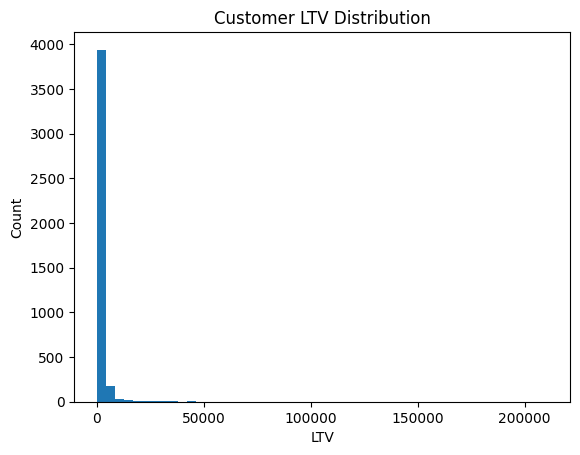

In [26]:
plt.figure()
plt.hist(rfm['Predicted_LTV'], bins=50)
plt.title("Customer LTV Distribution")
plt.xlabel("LTV")
plt.ylabel("Count")
plt.show()


In [27]:
rfm.to_csv('LTV_Predictions.csv')


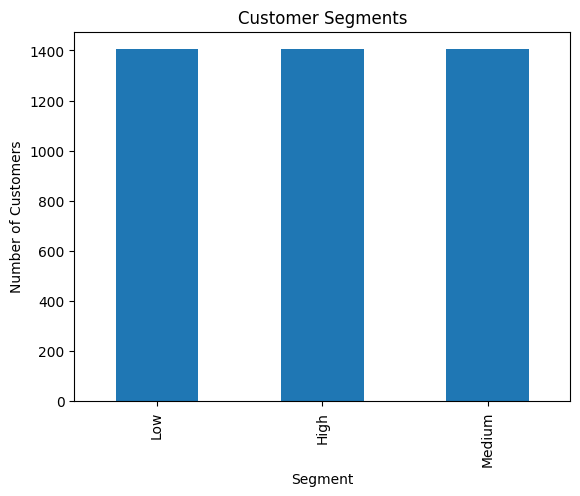

In [28]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()